In [1]:
"""
Cross-Asset Market Regime Detector using a Hidden Markov Model (HMM).

This script performs the following steps:
1.  Fetches cross-asset market and economic data (equities, bonds, commodities, volatility).
2.  Engineers features suitable for market regime analysis.
3.  Trains a Gaussian Hidden Markov Model (HMM) to identify distinct market regimes.
4.  Interprets and visualizes the identified regimes against the S&P 500 price history.
5.  Implements and backtests a Tactical Asset Allocation (TAA) strategy based on the regimes.
6.  Compares the TAA strategy's performance against a static 60/40 benchmark portfolio.
"""

"\nCross-Asset Market Regime Detector using a Hidden Markov Model (HMM).\n\nThis script performs the following steps:\n1.  Fetches cross-asset market and economic data (equities, bonds, commodities, volatility).\n2.  Engineers features suitable for market regime analysis.\n3.  Trains a Gaussian Hidden Markov Model (HMM) to identify distinct market regimes.\n4.  Interprets and visualizes the identified regimes against the S&P 500 price history.\n5.  Implements and backtests a Tactical Asset Allocation (TAA) strategy based on the regimes.\n6.  Compares the TAA strategy's performance against a static 60/40 benchmark portfolio.\n"

###Phase 1: Environment Setup & Data Acquisition

In [2]:

import pandas as pd
import numpy as np
import yfinance as yf
from fredapi import Fred
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
from datetime import datetime

In [3]:

# Set plot style for aesthetics
sns.set_style("whitegrid")
plt.style.use("seaborn-v0_8-whitegrid")

In [4]:
def fetch_data(tickers, start_date, end_date, fred_api_key):
    """
    Fetches market and economic data from Yahoo Finance and FRED.

    Args:
        tickers (dict): A dictionary of asset and economic indicator tickers.
        start_date (str): The start date for data fetching in 'YYYY-MM-DD' format.
        end_date (str): The end date for data fetching.
        fred_api_key (str): Your Federal Reserve Economic Data API key.

    Returns:
        pd.DataFrame: A cleaned DataFrame with weekly data.
    """
    print("Phase 1: Fetching and preparing data...")

    # Separate tickers by source
    yf_tickers = {k: v for k, v in tickers.items() if k not in ['T10Y2Y', 'HYG_SPREAD']}
    fred_tickers = {k: v for k, v in tickers.items() if k in ['T10Y2Y', 'HYG_SPREAD']}

    # Fetch data from Yahoo Finance
    yf_data_list = []
    for key, ticker in yf_tickers.items():
        data = yf.download(ticker, start=start_date, end=end_date, progress=False)['Close']
        data.name = key  # Directly set the name of the Series
        yf_data_list.append(data)

    market_data = pd.concat(yf_data_list, axis=1)

    # Fetch data from FRED
    fred = Fred(api_key=fred_api_key)
    fred_data_list = []
    for key, ticker in fred_tickers.items():
        data = fred.get_series(ticker, start_date, end_date)
        fred_data_list.append(data.rename(key))

    economic_data = pd.concat(fred_data_list, axis=1)

    # Combine, resample, and clean
    combined_df = pd.concat([market_data, economic_data], axis=1)
    combined_df_weekly = combined_df.resample('W-FRI').last()
    combined_df_weekly = combined_df_weekly.fillna(method='ffill').dropna()

    print("Data fetching complete.\n")
    return combined_df_weekly

###Phase 2: Feature Engineering

In [5]:
def engineer_features(data):
    """
    Engineers features for the HMM model.

    Args:
        data (pd.DataFrame): The raw weekly data.

    Returns:
        tuple: A tuple containing:
            - pd.DataFrame: Scaled features for the HMM.
            - pd.DataFrame: Unscaled returns for backtesting.
            - pd.DataFrame: Unscaled features for interpretation.
    """
    print("Phase 2: Engineering features...")

    # Calculate weekly returns for price-based assets
    features = data.copy()
    # Corrected column names based on the fetched data
    features['SPX_ret'] = features['^GSPC'].pct_change()  #percentage change
    features['GOLD_ret'] = features['GC=F'].pct_change()
    features['OIL_ret'] = features['CL=F'].pct_change()
    features['SHY_ret'] = features['SHY'].pct_change()
    features['USD_ret'] = features['DX-Y.NYB'].pct_change()

    # Define the feature set for the model using the engineered return column names
    feature_columns = ['SPX_ret', '^VIX', 'T10Y2Y', 'HYG_SPREAD', 'OIL_ret', 'GOLD_ret']
    model_features = features[feature_columns].dropna()

    # Separate returns for backtesting (ensure alignment with features)
    returns_for_backtest = features[['SPX_ret', 'GOLD_ret', 'OIL_ret']].loc[model_features.index]

    # Standardize features        #It removes the average and rescales data to a standard scale z= (x-mean)/sd
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(model_features)
    scaled_features_df = pd.DataFrame(scaled_features, index=model_features.index, columns=model_features.columns)

    print("Feature engineering complete.\n")
    return scaled_features_df, returns_for_backtest, model_features

###Phase 3: HMM Modeling & Regime Identification

In [6]:
def train_hmm_model(features, n_regimes=4, n_iter=1000, seed=42):
    """
    Initializes and fits the Gaussian HMM model.

    Args:
        features (pd.DataFrame): The scaled feature data.
        n_regimes (int): The number of hidden states (regimes) to find.
        n_iter (int): The number of iterations for the EM algorithm.
        seed (int): Random state for reproducibility.

    Returns:
        tuple: A tuple containing:
            - hmm.GaussianHMM: The trained HMM model.
            - np.array: The sequence of predicted regimes.
    """
    print("Phase 3: Training Hidden Markov Model...")

    model = hmm.GaussianHMM(
        n_components=n_regimes,
        covariance_type="full",
        n_iter=n_iter,
        random_state=seed
    )
    model.fit(features)
    regimes = model.predict(features)

    print("HMM training complete.\n")
    return model, regimes


###Phase 4: Regime Interpretation & Visualization

In [7]:
def interpret_and_plot_regimes(price_data, unscaled_features, regimes):
    """
    Analyzes and visualizes the characteristics of each market regime.

    Args:
        price_data (pd.DataFrame): Original price data (for plotting SPX).
        unscaled_features (pd.DataFrame): Unscaled feature data for interpretation.
        regimes (np.array): The predicted regime for each time step.
    """
    print("Phase 4: Interpreting and visualizing regimes...")

    # Align price data with features index
    aligned_price_data = price_data.loc[unscaled_features.index]

    # Analyze regime characteristics
    regime_features = unscaled_features.copy()
    regime_features['regime'] = regimes
    regime_summary = regime_features.groupby('regime').mean()

    print("--- Regime Feature Averages ---")
    print(regime_summary)
    print("-------------------------------\n")

    # Interpret and name regimes based on the summary table
    # This part is subjective and based on financial intuition.
    # E.g., High SPX_ret, low VIX -> Bull Market
    # E.g., Low SPX_ret, high VIX, high HYG_SPREAD -> Bear Market
    regime_names = {
        0: 'Bear Market / Risk-Off',
        1: 'Bull Market / Calm',
        2: 'Stagflation / Volatile',
        3: 'Recovery / Transition'
    }

    # --- Primary Visualization ---
    fig, ax = plt.subplots(figsize=(15, 8))

    # Plot S&P 500 price
    ax.plot(aligned_price_data.index, aligned_price_data['^GSPC'], color='black', linewidth=1.5, label='S&P 500 Index')
    ax.set_ylabel('S&P 500 Price')
    ax.set_title('Market Regimes Identified by HMM')
    ax.grid(False)

    # Shade background based on regime
    colors = ['red', 'green', 'orange', 'blue']
    for i in range(len(regime_names)):
        mask = (regimes == i)
        ax.fill_between(aligned_price_data.index, 0, aligned_price_data['^GSPC'].max() * 1.5,
                        where=mask, facecolor=colors[i], alpha=0.3, label=f'Regime {i}: {regime_names.get(i, "Unknown")}')


    ax.set_ylim(0, aligned_price_data['^GSPC'].max() * 1.1)
    ax.legend(loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.xlabel('Year')
    plt.tight_layout()

    print("Regime visualization created.\n")
    return regime_names

### Phase 5: Tactical Asset Allocation (TAA) Backtest

In [8]:

def calculate_performance_metrics(returns):
    """Calculates key performance metrics for a returns series."""
    weeks_per_year = 52
    total_weeks = len(returns)

    cumulative_returns = (1 + returns).cumprod()

    # Cumulative Annual Growth Rate (CAGR)
    cagr = (cumulative_returns.iloc[-1])**(weeks_per_year / total_weeks) - 1

    # Annualized Volatility
    volatility = returns.std() * np.sqrt(weeks_per_year)

    # Sharpe Ratio (assuming risk-free rate of 0)
    sharpe_ratio = cagr / volatility if volatility != 0 else 0

    # Maximum Drawdown
    running_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - running_max) / running_max
    max_drawdown = drawdown.min()

    return {
        "CAGR": f"{cagr:.2%}",
        "Annualized Volatility": f"{volatility:.2%}",
        "Sharpe Ratio": f"{sharpe_ratio:.2f}",
        "Maximum Drawdown": f"{max_drawdown:.2%}"
    }


In [9]:
def run_backtest(returns_df, regimes, allocation_dict):
    """
    Runs a backtest for the TAA strategy and an S&P 500 benchmark.
    """
    print("Phase 5: Running Tactical Asset Allocation Backtest...")

    backtest_data = returns_df.copy()
    backtest_data['regime'] = regimes

    # --- TAA Strategy ---
    taa_returns = []
    for i in range(len(backtest_data)):
        current_regime = backtest_data['regime'].iloc[i]
        weights = allocation_dict.get(current_regime, {'SPX': 1.0})

        weekly_return = 0
        for asset, weight in weights.items():
            asset_ret_col = f"{asset}_ret"
            if asset_ret_col in backtest_data.columns:
                weekly_return += backtest_data[asset_ret_col].iloc[i] * weight
        taa_returns.append(weekly_return)

    backtest_data['taa_returns'] = taa_returns

    # --- NEW BENCHMARK: 100% S&P 500 ---
    backtest_data['benchmark_returns'] = backtest_data['SPX_ret']

    # --- Performance Analysis ---
    taa_metrics = calculate_performance_metrics(backtest_data['taa_returns'])
    benchmark_metrics = calculate_performance_metrics(backtest_data['benchmark_returns'])

    print("\n--- Backtest Performance Metrics ---")
    print("Tactical Asset Allocation (TAA):")
    for metric, value in taa_metrics.items():
        print(f"  - {metric}: {value}")

    # --- UPDATED LABEL ---
    print("\nS&P 500 Benchmark:")
    for metric, value in benchmark_metrics.items():
        print(f"  - {metric}: {value}")

    # Calculate Alpha
    taa_cagr = float(taa_metrics['CAGR'].strip('%'))
    bench_cagr = float(benchmark_metrics['CAGR'].strip('%'))
    alpha = taa_cagr - bench_cagr
    print(f"\n**Strategy Alpha: {alpha:.2f}%**")
    print("------------------------------------\n")

    # Calculate cumulative returns for plotting
    taa_cumulative = (1 + backtest_data['taa_returns']).cumprod()
    benchmark_cumulative = (1 + backtest_data['benchmark_returns']).cumprod()

    # --- Plotting ---
    plt.figure(figsize=(15, 8))
    plt.plot(taa_cumulative, label=f'TAA Strategy (Alpha: {alpha:.2f}%)', color='blue')
    # --- UPDATED LABEL ---
    plt.plot(benchmark_cumulative, label='S&P 500 Benchmark', color='grey', linestyle='--')
    plt.title('Backtest: TAA Strategy vs. S&P 500 Benchmark')
    plt.ylabel('Cumulative Growth of $1')
    plt.xlabel('Year')
    plt.legend()
    plt.yscale('log')
    plt.tight_layout()

    print("Backtest visualization created.\n")
    return taa_cumulative, benchmark_cumulative

## Main Execution Block

Phase 1: Fetching and preparing data...


C:\Users\i2r-i\AppData\Local\Temp\ipykernel_32608\619086145.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False)['Close']
C:\Users\i2r-i\AppData\Local\Temp\ipykernel_32608\619086145.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False)['Close']
C:\Users\i2r-i\AppData\Local\Temp\ipykernel_32608\619086145.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False)['Close']
C:\Users\i2r-i\AppData\Local\Temp\ipykernel_32608\619086145.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False)['Close']
C:\Users\i2r-i\AppData\Local\Temp\ipykernel_32608\619086145.py:23: FutureWar

Data fetching complete.

Columns in fetched data: Index(['^GSPC', '^VIX', 'GC=F', 'CL=F', 'SHY', 'DX-Y.NYB', 'T10Y2Y',
       'HYG_SPREAD'],
      dtype='object')


Phase 2: Engineering features...
Feature engineering complete.

Phase 3: Training Hidden Markov Model...
HMM training complete.

Phase 4: Interpreting and visualizing regimes...
--- Regime Feature Averages ---
         SPX_ret       ^VIX    T10Y2Y  HYG_SPREAD   OIL_ret  GOLD_ret
regime                                                               
0      -0.000798  26.492500  0.863000    5.867269  0.003035  0.003579
1       0.002998  14.508600  0.263747    3.450813  0.002647  0.003641
2       0.003157  15.959083  1.850000    5.231953  0.000022 -0.000135
3      -0.003238  43.795814  2.106977   15.423023 -0.004180  0.002561
-------------------------------

Regime visualization created.

Phase 5: Running Tactical Asset Allocation Backtest...

--- Backtest Performance Metrics ---
Tactical Asset Allocation (TAA):
  - CAGR: 9.49%

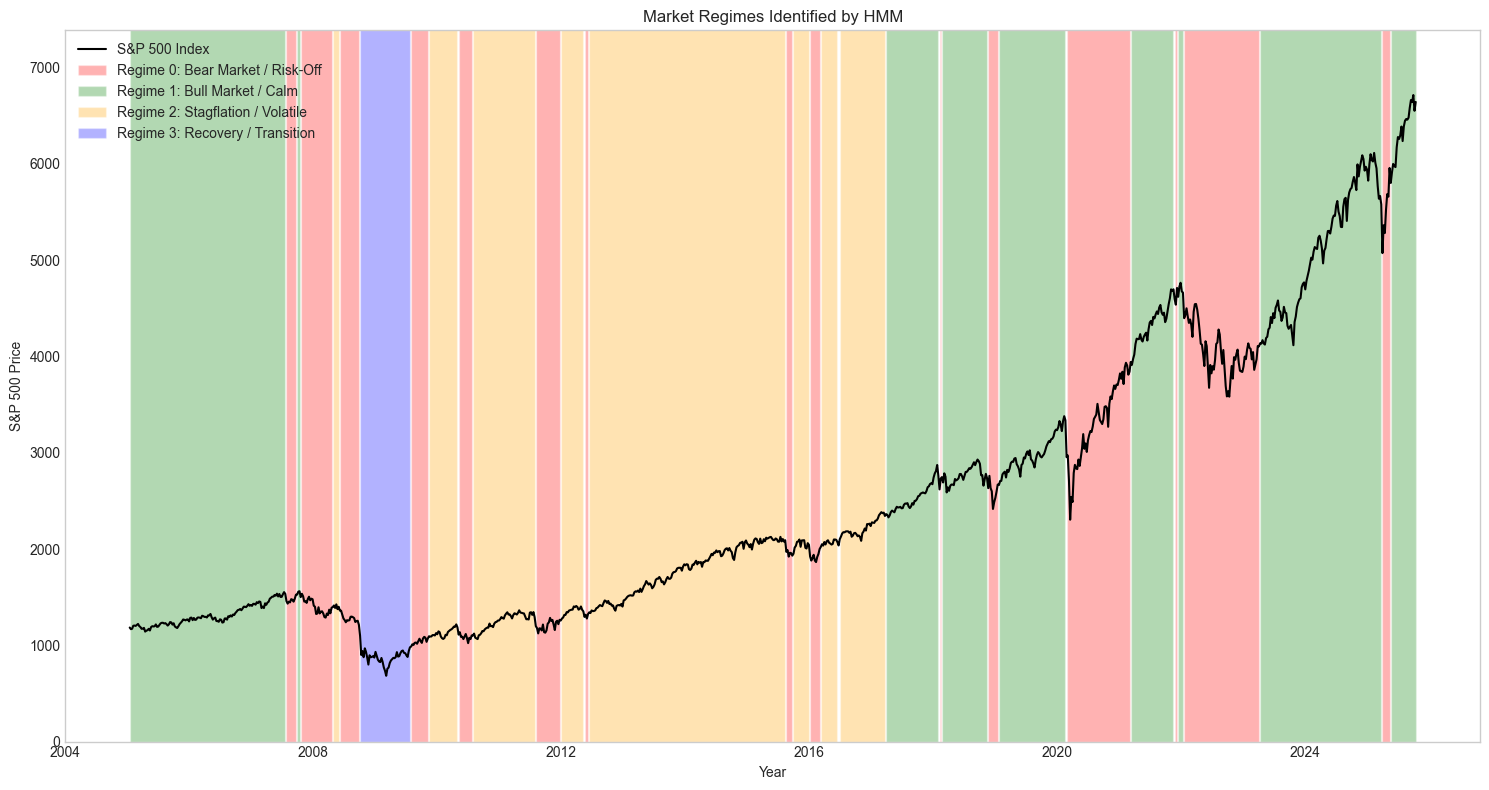

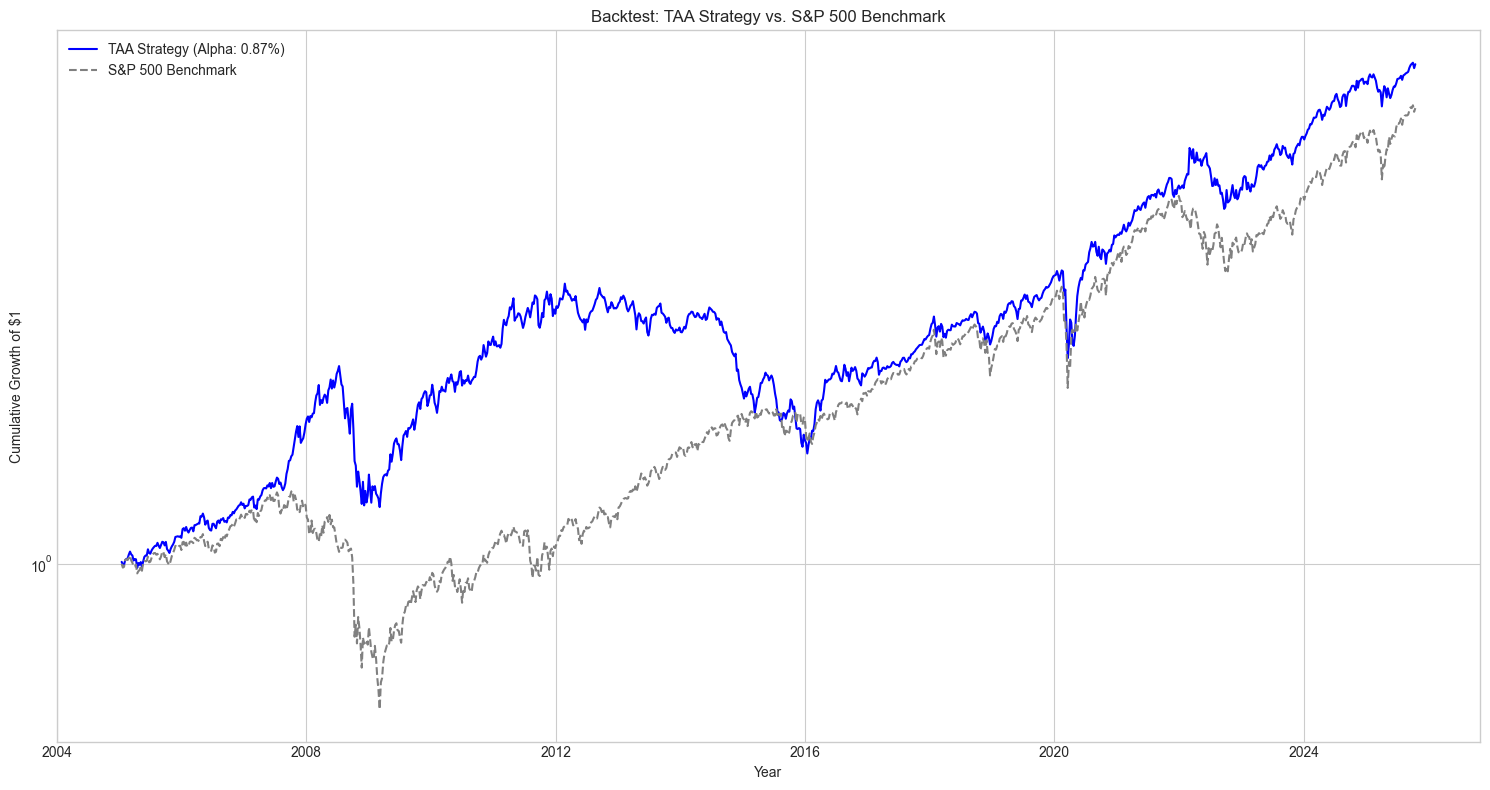

In [10]:

if __name__ == "__main__":
    # --- Configuration ---
    FRED_API_KEY = '04ba8ad63a3a886cc6d4e37c78c4c0af' # IMPORTANT: Replace with your actual key

    TICKERS = {
        # Equities & Volatility (Yahoo Finance)
        'SPX': '^GSPC',      # S&P 500 Index
        'VIX': '^VIX',       # CBOE Volatility Index
        # Commodities (Yahoo Finance)
        'GOLD': 'GC=F',      # Gold Futures
        'OIL': 'CL=F',       # Crude Oil Futures
        # Currencies (Yahoo Finance)
        'SHY': 'SHY',
        'USD': 'DX-Y.NYB',   # US Dollar Index
        # Bonds (FRED)
        'T10Y2Y': 'T10Y2Y',  # 10-Year vs 2-Year Treasury Yield Spread   ///// use T10Y3M
        'HYG_SPREAD': 'BAMLH0A0HYM2' # ICE BofA US High Yield Index Option-Adjusted Spread
    }

    START_DATE = '2005-01-01'
    END_DATE = '2025-10-15'

    if FRED_API_KEY == 'YOUR_API_KEY_HERE':
        raise ValueError("Please replace 'YOUR_API_KEY_HERE' with your actual FRED API key.")

    # --- Execute Pipeline ---

    # 1. Fetch Data
    raw_data = fetch_data(TICKERS, START_DATE, END_DATE, FRED_API_KEY)
    print("Columns in fetched data:", raw_data.columns)
    print('\n')

    # 2. Engineer Features
    scaled_features, returns, unscaled_features = engineer_features(raw_data)

    # 3. Train HMM
    model, regimes = train_hmm_model(scaled_features)

    # 4. Interpret & Visualize Regimes
    regime_names = interpret_and_plot_regimes(raw_data, unscaled_features, regimes)

    # 5. Define TAA Strategy & Run Backtest
    REGIME_ASSET_ALLOCATION = {
        # Regime 0: 'Bear Market / Risk-Off' -> Defensive assets like Gold
        0: {'SPX': 0.05, 'GOLD': 0.65, 'OIL': 0.30},
        # Regime 1: 'Bull Market / Calm' -> Pro-growth assets like Equities
        1: {'SPX': 0.80, 'GOLD': 0.10, 'OIL': 0.10},
        # Regime 2: 'Stagflation / Volatile' -> Inflation hedges like Gold and Oil
        2: {'SPX': 0.10, 'GOLD': 0.50, 'OIL': 0.40},
        # Regime 3: 'Recovery / Transition' -> Balanced, leaning towards growth
        3: {'SPX': 0.50, 'GOLD': 0.30, 'OIL': 0.20}
    }

    run_backtest(returns, regimes, REGIME_ASSET_ALLOCATION)

    # Display all generated plots
    plt.show()